# **Fisik vs. Digital: Analisis Perbandingan Kerentanan Media Penyimpanan Data Kesehatan US**
#### Kelompok 2:
1. Adhitya Bayu Pratama   : 5027261045
2. Via Nur Belaya         : 5027261060
3. Raditya Langit Nugraha : 5027261072
## *Topik: Cybersecurity - Data Breaches*

Data ini sangat menarik untuk diteliti karena tidak hanya memetakan jenis-jenis media penyimpanan data kesehatan yang paling rentan mengalami kebocoran, tetapi juga mengungkap secara pasti seberapa besar jumlah individu yang dirugikan dari setiap insiden tersebut. Dari temuan tersebut, analisis ini disusun untuk menjawab beberapa pertanyaan yang muncul guna memahami pola, karakteristik, dan tingkat keparahan risiko keamanan data medis secara menyeluruh yaitu:
- Berapa perbandingan proporsi dan frekuensi insiden kebocoran data antara media dokumen fisik (paper records) dan perangkat elektronik?
- Bagaimana distribusi jenis pelanggaran (Type of Breach) pada media fisik dibandingkan dengan digital?
- Tipe entitas kesehatan (Covered Entity Type) mana yang paling sering mengalami kebocoran data pada media dokumen fisik versus perangkat elektronik?

In [1]:
import pandas as pd
import numpy as np
import matplotlib as mt
import seaborn as sns
#Kumpulan library yang kita gunakan

print("Library berhasil dimasukan") #Memastikan library sudah ter execute atau ter import dengan menampilkan teks (yang berarti line diatasnya sudah berhasil di proses)

Library berhasil dimasukan


In [2]:
df = pd.read_csv('breach_report.csv', index_col=0) #Membaca file .csv yang kita mau proses
print("Jumlah baris, kolom:", df.shape) #Menyatakan ukuran dari data yang akan kita proses

df.index += 1 #agar index mulai dari 1, bukan 0

# Mengubah tipe data "Individuals Affected" dari float menjadi nullable integer
df['Individuals Affected'] = df['Individuals Affected'].astype('Int64')

pd.set_option('display.max_rows', None) #menampilkan semua data tanpa di limit

df.head() #Menampilkan 5 baris data paling atas

Jumlah baris, kolom: (1654, 9)


,Name of Covered Entity,State,Covered Entity Type,Individuals Affected,Breach Submission Date,Type of Breach,Location of Breached Information,Business Associate Present,Web Description
index,,,,,,,,,
1,Brooke Army Medical Center,TX,Healthcare Provider,1000,10/21/09,Theft,Paper/Films,No,A binder containing the protected health infor...
2,"Mid America Kidney Stone Association, LLC",MO,Healthcare Provider,1000,10/28/09,Theft,Network Server,No,Five desktop computers containing unencrypted ...
3,Alaska Department of Health and Social Services,AK,Healthcare Provider,501,10/30/09,Theft,"Other, Other Portable Electronic Device",No,\N
4,Health Services for Children with Special Need...,DC,Health Plan,3800,11/17/09,Loss,Laptop,No,A laptop was lost by an employee while in tran...
5,"Mark D. Lurie, MD",CA,Healthcare Provider,5166,11/20/09,Theft,Desktop Computer,No,A shared Computer that was used for backup was...


In [3]:
#Hapus kolom yang tidak diperlukan dan/atau tidak sesuai dengan tujuan analisis
df = df.drop(columns=['State', 'Breach Submission Date', 'Business Associate Present', 'Web Description']) 
df.head() #Nampilin 5 data pertama sebagai contoh

,Name of Covered Entity,Covered Entity Type,Individuals Affected,Type of Breach,Location of Breached Information
index,,,,,
1,Brooke Army Medical Center,Healthcare Provider,1000,Theft,Paper/Films
2,"Mid America Kidney Stone Association, LLC",Healthcare Provider,1000,Theft,Network Server
3,Alaska Department of Health and Social Services,Healthcare Provider,501,Theft,"Other, Other Portable Electronic Device"
4,Health Services for Children with Special Need...,Health Plan,3800,Loss,Laptop
5,"Mark D. Lurie, MD",Healthcare Provider,5166,Theft,Desktop Computer


## Deskripsi data dan kamus data ##

1. Sumber data dan Lisensi:
    - **License**: https://creativecommons.org/licenses/by/4.0/
        <br> **You are free to**:
        <br>**Share** - copy and redistribute the material in any medium or format for any purpose, even commercially.
        <br>**Adapt** - remix, transform, and build upon the material for any purpose, even commercially.
            <br> <br> **Under the following terms**:
              <br> **Attribution** - You must give appropriate credit, provide a link to the license, and indicate if changes were made. You may do so in any   reasonable manner, but not in any way that suggests the licensor endorses you or your use.
            <br> **No additional restrictions** - You may not apply legal terms or technological measures that legally restrict others from doing anything the license permits.
            <br> <br>**Notices**:
            <br> You do not have to comply with the license for elements of the material in the public domain or where your use is permitted by an applicable exception or limitation.
            <br> No warranties are given. The license may not give you all of the permissions necessary for your intended use. For example, other rights such as publicity, privacy, or moral rights may limit how you use the material.
      <br> <br> 
    - Source: https://www.kaggle.com/datasets/thedevastator/major-us-health-data-breaches,
        <br> Original source: data.world (Web discontinued) & HHS OCR Breach Portal: https://ocrportal.hhs.gov/ocr/breach/breach_report_hip.jsf
    <br>

2. Siapa yang mengumpulkan data? kapan? dan bagaimana?
    - Siapa: <br> Data ini dikumpulkan oleh **Office for Civil Rights (OCR)** di bawah naungan departemen kesehatan Amerika Serikat atau U.S. **Department of Health and Human Services (HHS)**. <br>
    - Kapan: <br> Data direkam secara berkelanjutan sejak **HIPAA Breach Notification Rule** mulai diberlakukan pada **tahun 2009**. Pengumpulannya dilakukan secara real-time dan **institusi wajib melaporkan insiden** ke HHS selambat-lambatnya 60 hari sejak **kebocoran pertama kali ditemukan**, bukan dihitung dari hari terjadinya kebocoran.   <br>
    - Bagaimana: <br> Data ini tidak dikumpulkan melalui survei atau pencarian independen oleh peneliti, melainkan lewat **mandat hukum wajib lapor** (HIPAA/HITECH Act)
   <br>

3. Jumlah baris dan kolom
   - Jumlah baris = 1654
   - Jumlah kolom = 5
    <br>
    
4. Kamus data untuk semua kolom yang dipakai, dengan format seperti tabel di bawah:

In [4]:
import pandas as pd

kamus_data = {
    "Kolom": [
        "Name of Covered Entity",
        "Covered Entity Type",
        "Individuals Affected",
        "Type of Breach",
        "Location of Breached Information"
    ],
    "Arti": [
        "The name of the entity (US Hospital) that experienced the data breach. (String)",
        "The type of entity that experienced the data breach, such as hospitals or insurers. (String)",
        "Individuals effected",
        "The type of breach that occurred, such as unauthorized access/disclosure or loss of hardware/electronic media. (String)",
        "The location of the breached information, such as paper records or electronic devices. (String)"
    ],
    "Jenis_variabel": [
        "Kualitatif",
        "Kualitatif",
        "Kuantitatif diskrit",
        "Kualitatif",
        "Kualitatif"
    ],
    "Skala": [
        "Nominal",
        "Nominal",
        "Ratio",
        "Nominal",
        "Nominal"
    ],
    "Satuan": ["-", "-", "-", "-", "-"],
    "Contoh": [
        "Brooke Army Medical Center",
        "Healthcare Provider",
        "1000",
        "Theft",
        "Paper/Films"
    ]
}

dtf = pd.DataFrame(kamus_data)
dtf.index = dtf.index + 1
dtf

,Kolom,Arti,Jenis_variabel,Skala,Satuan,Contoh
1,Name of Covered Entity,The name of the entity (US Hospital) that expe...,Kualitatif,Nominal,-,Brooke Army Medical Center
2,Covered Entity Type,The type of entity that experienced the data b...,Kualitatif,Nominal,-,Healthcare Provider
3,Individuals Affected,Individuals effected,Kuantitatif diskrit,Ratio,-,1000
4,Type of Breach,"The type of breach that occurred, such as unau...",Kualitatif,Nominal,-,Theft
5,Location of Breached Information,"The location of the breached information, such...",Kualitatif,Nominal,-,Paper/Films


## Pemeriksaan Kualitas Data ##

1. Cek tipe data setiap kolom

In [5]:
df.info()        # tipe data setiap kolom

<class 'pandas.DataFrame'>
RangeIndex: 1654 entries, 1 to 1654
Data columns (total 5 columns):
 #   Column                            Non-Null Count  Dtype
---  ------                            --------------  -----
 0   Name of Covered Entity            1654 non-null   str  
 1   Covered Entity Type               1613 non-null   str  
 2   Individuals Affected              1632 non-null   Int64
 3   Type of Breach                    1640 non-null   str  
 4   Location of Breached Information  1643 non-null   str  
dtypes: Int64(1), str(4)
memory usage: 66.4 KB


2. Cek jumlah data kosong (missing value) per kolom

In [6]:
df.isna().sum() # jumlah data kosong per kolom

Name of Covered Entity               0
Covered Entity Type                 41
Individuals Affected                22
Type of Breach                      14
Location of Breached Information    11
dtype: int64

In [7]:
df[df.isna().any(axis=1)] #menampilkan data yang kosong

,Name of Covered Entity,Covered Entity Type,Individuals Affected,Type of Breach,Location of Breached Information
index,,,,,
45,Wyoming Department of Health,Health Plan,9023,NaN,Network Server
55,"Computer Program and Systems, Inc. (CPSI)",Business Associate,768,NaN,Email
84,"Omaha Construction Industry , Privacy Manager ...",NaN,800,Theft,Laptop
121,Aetna,Health Plan,6372,NaN,Paper/Films
312,Lansing Community College,NaN,5000,Hacking/IT Incident,Network Server
315,Memorial Health Systems,NaN,<NA>,NaN,NaN
318,Windsor Health Plan,NaN,1378,Unauthorized Access/Disclosure,Paper/Films
327,"Ashley Industrial Molding, Inc. Employee Welfa...",NaN,506,Hacking/IT Incident,Network Server
357,MAPFRE Life,NaN,2209,Theft,Other


Keputusan dari kami adalah untuk **membuang data NaN atau missing value** tersebut. Karena sebagai berikut.

Persentase per kolom terhadap 1654 baris:

Covered Entity Type: 41 (2,48%) <br>
Individuals Affected: 22 (1,33%) <br>
Type of Breach: 14 (0,85%) <br>
Location of Breached Information: 11 (0,66%) <br>
Name of Covered Entity: 0 (0%)

Persentase data kosong pada tiap kolom **kecil**, berkisar 0,7% sampai 2,5% dari 1654 baris, sehingga penghapusan **tidak mengurangi tingkat representatif** dataset secara signifikan. Keempat kolom ini juga dipakai langsung dalam analisis, sehingga mengisi nilai kosong dengan estimasi berisiko menghasilkan kesimpulan yang keliru, terutama untuk kolom Individuals Affected yang bersifat numerik.

In [8]:
df = df.dropna()
df.isna().sum() #cek lagi

Name of Covered Entity              0
Covered Entity Type                 0
Individuals Affected                0
Type of Breach                      0
Location of Breached Information    0
dtype: int64

3. Cek jumlah baris yang ada duplikat

In [9]:
print(df.duplicated().sum())     # jumlah baris duplikat

3


In [10]:
df[df.duplicated(keep=False)] # menampilkan row data yang terduplikat

,Name of Covered Entity,Covered Entity Type,Individuals Affected,Type of Breach,Location of Breached Information
index,,,,,
322,Health Care Service Corporation,Health Plan,501,Theft,Paper/Films
513,SwedishAmerican Health System,Healthcare Provider,1500,Theft,Paper/Films
559,SwedishAmerican Health System,Healthcare Provider,1500,Theft,Paper/Films
1348,Health Care Service Corporation,Health Plan,501,Theft,Paper/Films
1446,Ecolab Health and Welfare Benefits Plan,Health Plan,1550,Hacking/IT Incident,Network Server
1447,Ecolab Health and Welfare Benefits Plan,Health Plan,1550,Hacking/IT Incident,Network Server


Hilangkan data yang terduplikasi

In [11]:
df_rapi = df
df_rapi = df_rapi.drop(index=[322,513,1446])
df_rapi['Individuals Affected'] = df_rapi['Individuals Affected'].astype('Int64')

print(df_rapi.duplicated().sum()) # cek kembali apakah ada duplikasi data

0


4. Nah ternyata kami menemukan bahwa di kolom Type of Breach dan kolom Location of Breached Information itu terdapat **multiple value** dalam 1 kolom. Maka dari itu, kita coba cek ada berapa jumlahnya.

In [12]:
multiple_value_type = df_rapi["Type of Breach"].astype(str).str.contains(", ")

print("Jumlah data dengan multiple value dalam kolom Type of Breach: ", (multiple_value_type).sum(), "\n")

multiple_value_loc = df_rapi["Location of Breached Information"].astype(str).str.contains(", ")

print("Jumlah data dengan multiple value dalam kolom Location of Breached Information: ", (multiple_value_loc).sum())

#df_rapi[multiple_value][["Type of Breach"]]

Jumlah data dengan multiple value dalam kolom Type of Breach:  80 

Jumlah data dengan multiple value dalam kolom Location of Breached Information:  198


In [13]:
#df_rapi[multiple_value][["Location of Breached Information"]] #untuk menampilkan datanya

Kita pisahkan menjadi baris sendiri-sendiri supaya tidak terdapat missing value (nanti akan mempengaruhi visualisasi datanya)

In [14]:
df_rapi['Type of Breach'] = df_rapi['Type of Breach'].str.split(', ')
df_rapi['Location of Breached Information'] = df_rapi['Location of Breached Information'].str.split(', ')
df_exploded = df_rapi.explode("Type of Breach").explode("Location of Breached Information")

#Memasukkan/menggabungakan kategori Unknown dalam Type of Breach kedalam Other 
df_exploded['Type of Breach'] = df_exploded['Type of Breach'].replace({'Unknown': 'Other'})

df_exploded.head() #contoh

,Name of Covered Entity,Covered Entity Type,Individuals Affected,Type of Breach,Location of Breached Information
index,,,,,
1,Brooke Army Medical Center,Healthcare Provider,1000,Theft,Paper/Films
2,"Mid America Kidney Stone Association, LLC",Healthcare Provider,1000,Theft,Network Server
3,Alaska Department of Health and Social Services,Healthcare Provider,501,Theft,Other
3,Alaska Department of Health and Social Services,Healthcare Provider,501,Theft,Other Portable Electronic Device
4,Health Services for Children with Special Need...,Health Plan,3800,Loss,Laptop


# Statistik Deskriptif Variabel Numerik #

**a) Mean, Median, Modus kolom 'Individuals Affected'**

Capping data karena terdapat outlier (terlalu tinggi perbedaan minimal dan maksimalnya)

In [24]:
df['Individuals Affected'] = df_rapi['Individuals Affected'].clip(upper=200000) #basically ngecap manual di 200 ribu

In [25]:
col_to_split = 'Type of Breach'
col_to_split1 = 'Location of Breached Information'
df[col_to_split] = df[col_to_split].astype(str).str.split(', ')
df[col_to_split1] = df[col_to_split1].astype(str).str.split(', ')
df_exploded = df.explode(col_to_split).reset_index(drop=True)
df_exploded = df.explode(col_to_split1).reset_index(drop=True)

In [26]:
kolom = df['Individuals Affected']
kolom.mean(), kolom.median(), kolom.mode()[0]
kolom.var(), kolom.std()
kolom.quantile(0.25), kolom.quantile(0.75)
df.describe()

,Individuals Affected
count,1596.0
mean,13811.175439
std,37308.08041
min,500.0
25%,990.5
50%,2300.0
75%,7500.0
max,200000.0


**b) Mean, Median, Modus kolom 'Type of Breach'**

Mengubah menjadi kolom numerik dengan manual mapping, di mana kita memberikan value secara manual pada setiap kategori dan membuat kolom baru untuk mencari mean, median, dan modus kolom tersebut.

In [27]:
type_mapping = {
    'Theft': 1,
    'Loss': 2,
    'Other': 3,
    'Hacking/IT Incident': 4,
    'Improper Disposal': 5,
    'Unauthorized Access/Disclosure': 6
}
df_exploded['Type of Breach Code'] = df_exploded['Type of Breach'].str[0].map(type_mapping) #di apply ke df_exploded dan diubah ke bentuk string
df_exploded.head()
df_exploded.drop(['Type of Breach Code'],axis=1) #ini tadi ke double run jadi di hapus tiap di run code nya

,Name of Covered Entity,Covered Entity Type,Individuals Affected,Type of Breach,Location of Breached Information
0,Brooke Army Medical Center,Healthcare Provider,1000,[Theft],Paper/Films
1,"Mid America Kidney Stone Association, LLC",Healthcare Provider,1000,[Theft],Network Server
2,Alaska Department of Health and Social Services,Healthcare Provider,501,[Theft],Other
3,Alaska Department of Health and Social Services,Healthcare Provider,501,[Theft],Other Portable Electronic Device
4,Health Services for Children with Special Need...,Health Plan,3800,[Loss],Laptop
5,"Mark D. Lurie, MD",Healthcare Provider,5166,[Theft],Desktop Computer
6,"L. Douglas Carlson, M.D.",Healthcare Provider,5257,[Theft],Desktop Computer
7,"David I. Cohen, MD",Healthcare Provider,857,[Theft],Desktop Computer
8,"Michele Del Vicario, MD",Healthcare Provider,6145,[Theft],Desktop Computer
9,"Joseph F. Lopez, MD",Healthcare Provider,952,[Theft],Desktop Computer


In [28]:
kolom = df_exploded['Type of Breach Code']
kolom.mean(), kolom.median(), kolom.mode()[0]
kolom.var(), kolom.std()
kolom.quantile(0.25), kolom.quantile(0.75)
df_exploded['Type of Breach Code'].describe() #ngejelasin tipe datanya

count    1860.000000
mean        2.856452
std         2.043196
min         1.000000
25%         1.000000
50%         2.000000
75%         5.000000
max         6.000000
Name: Type of Breach Code, dtype: float64

**c) Mean, Median, Modus kolom 'Type of Breach'**

In [29]:
type_mapping1 = {
    'Paper/Films': 1,
    'Network Server': 2,
    'Other': 3,
    'Other Portable Electronic Device': 4,
    'Laptop': 5,
    'Desktop Computer': 6,
    'Electronic Medical Record': 7,
    'Email': 8
}
df_exploded['Location of Breached Information Code'] = df_exploded['Location of Breached Information'].map(type_mapping1) #di apply ke df_exploded
df_exploded.head()
df_exploded.drop(['Location of Breached Information Code'],axis=1) #ini tadi ke double run jadi di hapus tiap di run code nya

,Name of Covered Entity,Covered Entity Type,Individuals Affected,Type of Breach,Location of Breached Information,Type of Breach Code
0,Brooke Army Medical Center,Healthcare Provider,1000,[Theft],Paper/Films,1.0
1,"Mid America Kidney Stone Association, LLC",Healthcare Provider,1000,[Theft],Network Server,1.0
2,Alaska Department of Health and Social Services,Healthcare Provider,501,[Theft],Other,1.0
3,Alaska Department of Health and Social Services,Healthcare Provider,501,[Theft],Other Portable Electronic Device,1.0
4,Health Services for Children with Special Need...,Health Plan,3800,[Loss],Laptop,2.0
5,"Mark D. Lurie, MD",Healthcare Provider,5166,[Theft],Desktop Computer,1.0
6,"L. Douglas Carlson, M.D.",Healthcare Provider,5257,[Theft],Desktop Computer,1.0
7,"David I. Cohen, MD",Healthcare Provider,857,[Theft],Desktop Computer,1.0
8,"Michele Del Vicario, MD",Healthcare Provider,6145,[Theft],Desktop Computer,1.0
9,"Joseph F. Lopez, MD",Healthcare Provider,952,[Theft],Desktop Computer,1.0


In [30]:
kolom = df_exploded['Location of Breached Information Code']
kolom.mean(), kolom.median(), kolom.mode()[0]
kolom.var(), kolom.std()
kolom.quantile(0.25), kolom.quantile(0.75)
df_exploded['Location of Breached Information Code'].describe()

count    1869.000000
mean        3.822365
std         2.238822
min         1.000000
25%         2.000000
50%         4.000000
75%         5.000000
max         8.000000
Name: Location of Breached Information Code, dtype: float64

# Visualisasi Data #

Dalam bentuk:
1. Histogram -> Bentuk sebarannya
2. Boxplot -> Pencilan menurut aturan 1,5 × IQR
3. Diagram batang -> Perbandingan antar variabel

### Histogram ##

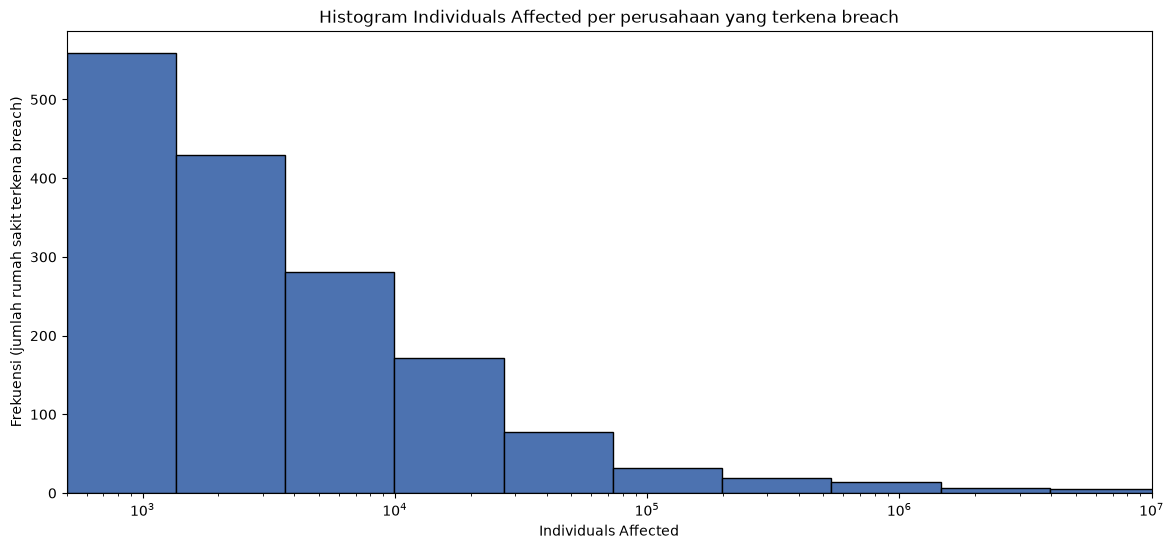

Range_Affected
(500.0, 1355.501]               559
(1355.501, 3674.763]            429
(3674.763, 9962.287]            281
(9962.287, 27007.771]           171
(27007.771, 73218.095]           77
(73218.095, 198494.332]          32
(198494.332, 538118.342]         19
(538118.342, 1458839.385]        14
(1458839.385, 3954915.093]        7
(3954915.093, 10721778.937]       5
(10721778.937, 29066753.864]      1
Name: count, dtype: int64


In [31]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

data = df_rapi["Individuals Affected"] 

log_bins = np.logspace(np.log10(data.min()), np.log10(data.max()), 13) 

fig, ax = plt.subplots(figsize=(14, 6))
ax.hist(data, bins= log_bins, color="#4C72B0", edgecolor="black")
ax.set_xscale("log") # Kita set sumbu x nya menggunakan log 10 (10 pangkat), karena datanya terdapat outlier yang SANGAT ekstrem
ax.set_title("Histogram Individuals Affected per perusahaan yang terkena breach")
ax.set_xlabel("Individuals Affected")
ax.set_ylabel("Frekuensi (jumlah rumah sakit terkena breach)")
plt.xlim(5e2 , 1e7)
plt.savefig("hist_individuals_affected_log_bins.png", dpi=150)
plt.show()

df_binned = df_rapi.copy()
df_binned["Range_Affected"] = pd.cut(data, bins=log_bins)

freq_table = df_binned["Range_Affected"].value_counts().sort_index()
freq_table_clean = freq_table[freq_table > 0]
print(freq_table_clean)

**Sebaran data miring ke kanan (right-skewed).** Hal ini berarti sebagian besar perusahaan hanya berdampak ke 500 sampai ribuan individu, dan hanya sedikit yang sampai menembus 10^6 atau bahkan 10^7 individu. Skala log dipakai karena pada skala biasa hampir seluruh data akan menumpuk di satu batang.

### Bar Chart ###

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns

breach_counts = df_exploded['Type of Breach'].value_counts() 

fig, ax = plt.subplots()
ax.bar(breach_counts.index, breach_counts.values, color="#C44E52", edgecolor="black")
ax.set_title("Jumlah perusahaan per Type of Breach")
ax.set_xlabel("Type of Breach")
ax.set_ylabel("Jumlah Kejadian")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig("bar_type_of_breach.png", dpi=150)
plt.show()

print(breach_counts)


**Theft** adalah penyebab **terbanyak** (sekitar 900 kejadian), hampir **dua kali lipat Unauthorized Access/Disclosure** (sekitar 480), disusul Hacking/IT Incident (sekitar 270).**Improper Disposal paling jarang** (sekitar 60), yang berarti **pencurian fisik masih lebih sering terjadi daripada serangan siber**.

In [ ]:
location_counts = df_exploded['Location of Breached Information'].value_counts()

fig, ax = plt.subplots()
ax.bar(location_counts.index, location_counts.values, color="#55A868", edgecolor="black")
ax.set_title("Jumlah perusahaan per Location of Breached Information")
ax.set_xlabel("Location of Breached Information")
ax.set_ylabel("Jumlah Kejadian")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig("bar_location_of_breach.png", dpi=150)
plt.show()

print(location_counts)

**Paper/Films** adalah **lokasi terbanyak** (sekitar 430 kejadian), diikuti **Laptop** (sekitar 350) dan **Network Server** (sekitar 300), sedangkan **Electronic Medical Record paling sedikit** (sekitar 100). **Lokasi yang paling sering bocor belum tentu yang paling berdampak**. Contohnya Paper/Films paling sering, tetapi pada boxplot ke-2 setelah ini mediannya justru paling rendah.

### Box Plot ###

In [ ]:
import numpy as np

# Buang baris yang Type of Breach-nya kosong (NaN)
kategori_breach = df_exploded["Type of Breach"].unique()

data_per_breach = [
    df_exploded.loc[df_exploded["Type of Breach"] == kat, "Individuals Affected"].dropna()
    for kat in kategori_breach
]

fig, ax = plt.subplots(figsize=(10, 6))
ax.boxplot(data_per_breach, tick_labels=kategori_breach, patch_artist=True,
           boxprops=dict(facecolor="#C44E52"))
ax.set_yscale("log")   # kunci biar kotak keliatan
ax.set_title("Boxplot Jumlah Individuals Affected per Type of Breach per Perusahaan")
ax.set_xlabel("Type of Breach")
ax.set_ylabel("Individu terdampak")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig("boxplot_by_breach_type.png", dpi=150)
plt.show()

**Hacking/IT Incident punya median tertinggi** (sekitar 4 ribu), **kotak terlebar, dan pencilan terbesar** (sekitar 80.000 ribu orang). Hal ini menunjukkan jenis breach ini **paling berisiko berdampak sangat luas** dibanding jenis lainnya. Kategori lain bermedian sekitar 2 ribu dengan kotak yang mirip. Pencilan menurut aturan 1,5 × IQR muncul di semua kategori, dan semuanya di sisi atas, jumlah paling banyak terdapat pada Theft, Hacking/IT Incident, dan Unauthorized Access/Disclosure.

In [ ]:
# Buang kategori kosong (NaN) juga di sini
kategori_lokasi = df_exploded["Location of Breached Information"].unique()

data_per_lokasi = [
    df_exploded.loc[df_exploded["Location of Breached Information"] == kat, "Individuals Affected"].dropna()
    for kat in kategori_lokasi
]

fig, ax = plt.subplots(figsize=(10, 6))
ax.boxplot(data_per_lokasi, tick_labels=kategori_lokasi, patch_artist=True,
           boxprops=dict(facecolor="#55A868"))
ax.set_yscale("log")   # biar kotak keliatan
ax.set_title("Boxplot Jumlah Individuals Affected per Location of Breached Information per Perusahaan")
ax.set_xlabel("Location of Breached Information")
ax.set_ylabel("Individu terdampak")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig("boxplot_by_location.png", dpi=150)
plt.show()

Semua kategori punya pencilan di atas batas atas (Q3 + 1,5 × IQR), tetapi tidak ada pencilan bawah karena batas bawah bernilai negatif dan whisker bawah sudah berhenti di nilai minimum (sekitar 0,5 ribu orang). **Network Server punya median tertinggi** (sekitar 6,5 ribu) **dan outlier ekstrem** sekitar 80.000 ribu orang, sedangkan **Paper/Films punya median terendah** (sekitar 1,5 ribu).

Seperti yang telah di mention di diagram ke-3, walaupun **Paper/Films** merupakan lokasi dengan jumlah kejadian terbanyak, tetapi lokasi tersebut memiliki **median yang paling rendah**. Yang berarti setiap kejadian di lokasi ini memiliki **resiko yang paling kecil untuk berdampak ke banyak individu**.